# 06 - Graduated Compression Curve

Generate five compression levels of each COT (light, medium, heavy, ultra-heavy, single-sentence),
then prefill PRIMARY_MODEL with each. Plot accuracy as a function of compression level.

The *shape* of this curve characterises legibility: a sharp cliff means a phase transition;
a gentle slope means information is distributed continuously across surface features.

In [1]:
import subprocess, sys
from pathlib import Path

WORKSPACE = Path("/workspace/13-4-2026")
REPO_DIR = WORKSPACE / "legibility"

if REPO_DIR.exists():
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)
else:
    WORKSPACE.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "-b", "13-4-2026",
        "https://github.com/JackHopkins/legibility.git",
        str(REPO_DIR)
    ], check=True)

sys.path.insert(0, str(REPO_DIR))
from lib.config import *

for d in [CACHE_DIR, COT_CACHE, PARAPHRASE_CACHE, PREFILL_CACHE, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

Already up to date.


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from lib.prompts import COMPRESSION_LEVELS, build_compression_messages
from lib.data import extract_predicted_answer
from lib.prefill import run_prefill_condition
from lib.paraphrase import clean_paraphrase

# Load all COTs from the core run
cots = []
for p in sorted(COT_CACHE.glob("*.json")):
    cots.append(json.loads(p.read_text()))
print(f"Loaded {len(cots)} COTs")

LEVELS = ["light", "medium", "heavy", "ultra_heavy", "single_sentence"]

## Phase 1: Generate compressed versions at all levels

Light and heavy already exist from 03_paraphrase. Generate medium, ultra_heavy, single_sentence.

In [ ]:
# Purge contaminated cache: delete any paraphrase/compress files containing <think> tags
import re

purge_prefixes = ["compress_medium", "compress_ultra_heavy", "compress_single_sentence",
                  "paraphrase_light", "paraphrase_heavy"]
total_purged = 0
for prefix in purge_prefixes:
    for p in PARAPHRASE_CACHE.glob(f"{prefix}_*.json"):
        try:
            r = json.loads(p.read_text())
            if "<think>" in r.get("paraphrased_cot", ""):
                p.unlink()
                total_purged += 1
        except Exception:
            pass

# Also purge the prefill results that depended on contaminated paraphrases
prefill_purge = ["compress_light_self", "compress_medium_self", "compress_heavy_self",
                 "compress_ultra_heavy_self", "compress_single_sentence_self"]
prefill_purged = 0
for prefix in prefill_purge:
    for p in PREFILL_CACHE.glob(f"{prefix}_*.json"):
        p.unlink()
        prefill_purged += 1

print(f"Purged {total_purged} contaminated paraphrase cache files")
print(f"Purged {prefill_purged} dependent prefill cache files")

In [3]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

# Only need to generate new levels
new_levels = ["medium", "ultra_heavy", "single_sentence"]

# Check what's already done
for level in LEVELS:
    condition = f"compress_{level}"
    n = len(list(PARAPHRASE_CACHE.glob(f"{condition}_*.json")))
    print(f"{condition}: {n} cached")

# Also count existing paraphrase_light and paraphrase_heavy
n_light = len(list(PARAPHRASE_CACHE.glob("paraphrase_light_*.json")))
n_heavy = len(list(PARAPHRASE_CACHE.glob("paraphrase_heavy_*.json")))
print(f"\nExisting: paraphrase_light={n_light}, paraphrase_heavy={n_heavy}")

compress_light: 0 cached
compress_medium: 0 cached
compress_heavy: 0 cached
compress_ultra_heavy: 0 cached
compress_single_sentence: 0 cached

Existing: paraphrase_light=1319, paraphrase_heavy=1319


In [4]:
print(f"Loading {PARAPHRASER_MODEL}...")
llm = LLM(model=PARAPHRASER_MODEL, dtype="bfloat16", max_model_len=4096)
tokenizer = AutoTokenizer.from_pretrained(PARAPHRASER_MODEL)
print("Paraphraser loaded.")

Loading Qwen/Qwen3-8B...
INFO 04-13 11:12:11 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 4096, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-8B'}
INFO 04-13 11:12:11 [model.py:533] Resolved architecture: Qwen3ForCausalLM
INFO 04-13 11:12:11 [model.py:1582] Using max model len 4096
INFO 04-13 11:12:11 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 04-13 11:12:11 [vllm.py:754] Asynchronous scheduling is enabled.
(EngineCore pid=82586) INFO 04-13 11:12:12 [core.py:103] Initializing a V1 LLM engine (v0.18.0) with config: model='Qwen/Qwen3-8B', speculative_config=None, tokenizer='Qwen/Qwen3-8B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_

(EngineCore pid=82586) <frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=82586) <frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]


(EngineCore pid=82586) INFO 04-13 11:12:36 [default_loader.py:384] Loading weights took 20.19 seconds
(EngineCore pid=82586) INFO 04-13 11:12:36 [gpu_model_runner.py:4566] Model loading took 15.27 GiB memory and 21.049882 seconds
(EngineCore pid=82586) INFO 04-13 11:12:39 [backends.py:988] Using cache directory: /root/.cache/vllm/torch_compile_cache/8fc724e697/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=82586) INFO 04-13 11:12:39 [backends.py:1048] Dynamo bytecode transform time: 2.46 s
(EngineCore pid=82586) INFO 04-13 11:12:41 [backends.py:284] Directly load the compiled graph(s) for compile range (1, 16384) from the cache, took 1.629 s
(EngineCore pid=82586) INFO 04-13 11:12:41 [monitor.py:48] torch.compile took 4.71 s in total
(EngineCore pid=82586) INFO 04-13 11:12:41 [decorators.py:296] Directly load AOT compilation from path /root/.cache/vllm/torch_compile_cache/torch_aot_compile/cc5a8a7ad433ab700b614c0db8aacedd8a663e83e6a5382b8d833c2d8294081a/rank_0_0/model
(Engi

(EngineCore pid=82586) 2026-04-13 11:12:43,727 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=82586) 2026-04-13 11:12:43,739 - INFO - autotuner.py:268 - flashinfer.jit: [Autotuner]: Autotuning process ends
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 25.06it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 51/51 [00:01<00:00, 37.46it/s]


(EngineCore pid=82586) INFO 04-13 11:12:47 [gpu_model_runner.py:5746] Graph capturing finished in 4 secs, took 0.97 GiB
(EngineCore pid=82586) INFO 04-13 11:12:47 [gpu_worker.py:617] CUDA graph pool memory: 0.97 GiB (actual), 0.84 GiB (estimated), difference: 0.12 GiB (12.9%).
(EngineCore pid=82586) INFO 04-13 11:12:47 [core.py:281] init engine (profile, create kv cache, warmup model) took 11.05 seconds
INFO 04-13 11:12:48 [llm.py:391] Supported tasks: ['generate']
Paraphraser loaded.


In [ ]:
sampling = SamplingParams(temperature=TEMPERATURE, max_tokens=MAX_COT_TOKENS)

for level in new_levels:
    condition = f"compress_{level}"
    done_ids = {
        int(p.stem.split("_", 2)[-1])
        for p in PARAPHRASE_CACHE.glob(f"{condition}_*.json")
    }
    todo = [c for c in cots if c["problem_id"] not in done_ids]
    print(f"[{condition}] {len(done_ids)} done, {len(todo)} remaining")

    for i in tqdm(range(0, len(todo), CHUNK_SIZE), desc=condition):
        chunk = todo[i:i + CHUNK_SIZE]
        messages_batch = [build_compression_messages(c["cot_text"], level) for c in chunk]
        prompts = []
        for msgs in messages_batch:
            try:
                prompt = tokenizer.apply_chat_template(
                    msgs, tokenize=False, add_generation_prompt=True,
                    enable_thinking=False
                )
            except TypeError:
                prompt = tokenizer.apply_chat_template(
                    msgs, tokenize=False, add_generation_prompt=True
                )
            prompts.append(prompt)

        outputs = llm.generate(prompts, sampling)

        for c, output in zip(chunk, outputs):
            raw = output.outputs[0].text.strip()
            cleaned = clean_paraphrase(raw)
            result = {
                "problem_id": c["problem_id"],
                "condition": condition,
                "original_cot": c["cot_text"],
                "paraphrased_cot": cleaned,
            }
            path = PARAPHRASE_CACHE / f"{condition}_{c['problem_id']}.json"
            path.write_text(json.dumps(result))

print("All compression levels generated.")

In [6]:
del llm
import gc; gc.collect()
import torch; torch.cuda.empty_cache()

## Phase 2: Prefill PRIMARY_MODEL with each compression level

In [7]:
from lib.data import load_gsm8k
dataset = load_gsm8k()

# Build lookup for each compression level
def load_compression_lookup(level):
    # For light/heavy, reuse existing paraphrase cache
    if level == "light":
        prefix = "paraphrase_light"
    elif level == "heavy":
        prefix = "paraphrase_heavy"
    else:
        prefix = f"compress_{level}"

    lookup = {}
    for p in PARAPHRASE_CACHE.glob(f"{prefix}_*.json"):
        r = json.loads(p.read_text())
        lookup[r["problem_id"]] = r["paraphrased_cot"]
    return lookup

compression_lookups = {level: load_compression_lookup(level) for level in LEVELS}
for level, lookup in compression_lookups.items():
    print(f"{level}: {len(lookup)} entries")

light: 1319 entries
medium: 1319 entries
heavy: 1319 entries
ultra_heavy: 1319 entries
single_sentence: 1319 entries


In [8]:
print(f"Loading {PRIMARY_MODEL}...")
llm = LLM(model=PRIMARY_MODEL, dtype="bfloat16", max_model_len=4096)
print("PRIMARY_MODEL loaded.")

for level in LEVELS:
    condition = f"compress_{level}_self"
    run_prefill_condition(llm, condition, PRIMARY_MODEL, dataset, compression_lookups[level])

del llm
import gc; gc.collect()
import torch; torch.cuda.empty_cache()

Loading Qwen/Qwen3-4B...
INFO 04-13 11:27:50 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 4096, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-4B'}
INFO 04-13 11:27:50 [model.py:533] Resolved architecture: Qwen3ForCausalLM
INFO 04-13 11:27:50 [model.py:1582] Using max model len 4096
INFO 04-13 11:27:50 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=16384.
(EngineCore pid=83020) INFO 04-13 11:27:51 [core.py:103] Initializing a V1 LLM engine (v0.18.0) with config: model='Qwen/Qwen3-4B', speculative_config=None, tokenizer='Qwen/Qwen3-4B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_retur

(EngineCore pid=83020) <frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=83020) <frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


(EngineCore pid=83020) INFO 04-13 11:28:04 [default_loader.py:384] Loading weights took 9.78 seconds
(EngineCore pid=83020) INFO 04-13 11:28:04 [gpu_model_runner.py:4566] Model loading took 7.56 GiB memory and 10.651202 seconds
(EngineCore pid=83020) INFO 04-13 11:28:07 [backends.py:988] Using cache directory: /root/.cache/vllm/torch_compile_cache/d901e9cfba/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=83020) INFO 04-13 11:28:07 [backends.py:1048] Dynamo bytecode transform time: 2.45 s
(EngineCore pid=83020) INFO 04-13 11:28:09 [backends.py:284] Directly load the compiled graph(s) for compile range (1, 16384) from the cache, took 1.999 s
(EngineCore pid=83020) INFO 04-13 11:28:09 [monitor.py:48] torch.compile took 4.98 s in total
(EngineCore pid=83020) INFO 04-13 11:28:09 [decorators.py:296] Directly load AOT compilation from path /root/.cache/vllm/torch_compile_cache/torch_aot_compile/4e195b79173bccf0a14b451a6eccb9cf2648d1e2abf7430eb706533af60dd7dd/rank_0_0/model
(Engine

(EngineCore pid=83020) 2026-04-13 11:28:11,297 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=83020) 2026-04-13 11:28:11,309 - INFO - autotuner.py:268 - flashinfer.jit: [Autotuner]: Autotuning process ends
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 25.12it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 51/51 [00:01<00:00, 39.84it/s]


...

compress_single_sentence_self:  95%|█████████▌| 20/21 [00:15<00:00,  1.35it/s]

Rendering prompts:   0%|          | 0/39 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/39 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

compress_single_sentence_self: 100%|██████████| 21/21 [00:15<00:00,  1.33it/s]

(EngineCore pid=83020) INFO 04-13 11:30:08 [core.py:1201] Shutdown initiated (timeout=0)
(EngineCore pid=83020) INFO 04-13 11:30:08 [core.py:1224] Shutdown complete


## Analysis: Compression curve

In [9]:
# Compute accuracy at each compression level
level_labels = ["Verbatim", "Light", "Medium", "Heavy", "Ultra-heavy", "Single sent."]
level_conditions = ["self_prefill"] + [f"compress_{l}_self" for l in LEVELS]

accs = []
cis = []

def bootstrap_ci(arr, n=10000, seed=42):
    rng = np.random.RandomState(seed)
    boots = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n)]
    boots = np.sort(boots)
    return boots[int(0.025 * n)], boots[int(0.975 * n)]

for cond in level_conditions:
    results = []
    for p in PREFILL_CACHE.glob(f"{cond}_*.json"):
        r = json.loads(p.read_text())
        results.append(r["predicted_answer"] == r["gold_answer"])
    if results:
        arr = np.array(results, dtype=float)
        acc = arr.mean()
        lo, hi = bootstrap_ci(arr)
        accs.append(acc)
        cis.append([acc - lo, hi - acc])
    else:
        accs.append(np.nan)
        cis.append([0, 0])
    print(f"{cond:30s}: {accs[-1]:.3f}")

# No-COT baseline
nc_results = []
for p in PREFILL_CACHE.glob("no_cot_*.json"):
    r = json.loads(p.read_text())
    nc_results.append(r["predicted_answer"] == r["gold_answer"])
no_cot_acc = np.mean(nc_results) if nc_results else 0

self_prefill                  : 0.803
compress_light_self           : 0.911
compress_medium_self          : 0.902
compress_heavy_self           : 0.913
compress_ultra_heavy_self     : 0.892
compress_single_sentence_self : 0.914


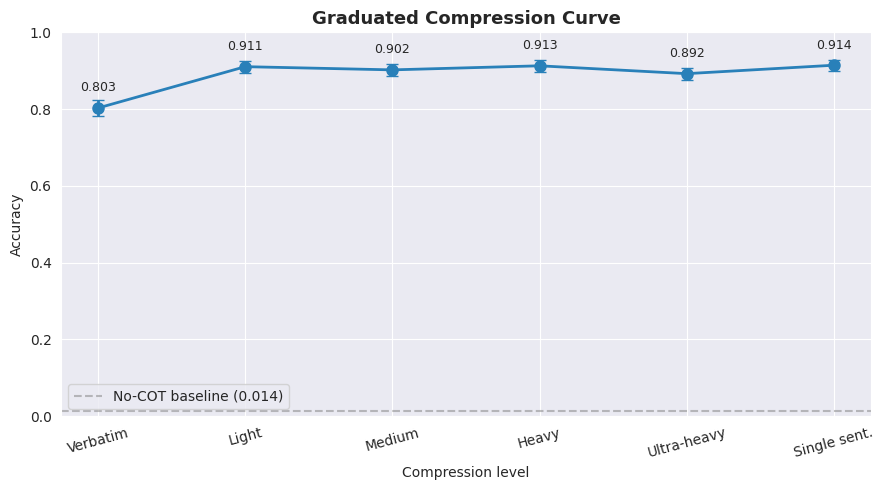

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ci_arr = np.array(cis).T
valid = [i for i, a in enumerate(accs) if not np.isnan(a)]

ax.errorbar(
    [i for i in valid], [accs[i] for i in valid],
    yerr=[[ci_arr[0][i] for i in valid], [ci_arr[1][i] for i in valid]],
    marker="o", capsize=4, linewidth=2, markersize=8, color="#2980b9",
)
ax.axhline(y=no_cot_acc, color="gray", linestyle="--", alpha=0.5, label=f"No-COT baseline ({no_cot_acc:.3f})")

ax.set_xticks(range(len(level_labels)))
ax.set_xticklabels(level_labels, rotation=15)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Compression level")
ax.set_title("Graduated Compression Curve", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
ax.legend()

for i in valid:
    ax.annotate(f"{accs[i]:.3f}", (i, accs[i]), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_curve.png", dpi=200, bbox_inches="tight")
plt.show()